In [ ]:
###########################################################
# This script generate composities from tiff files
###########################################################

In [2]:
import sys
from osgeo import gdal, gdalconst
import os
import glob
from matplotlib import pyplot as plt
import re
import numpy as np
from sklearn import preprocessing as pre
from skimage import exposure

plt.rcParams["figure.figsize"] = (20, 10)

In [24]:
def export_tiff(init_tiff, data, out_fname):
    '''
    Write geotiff file based on the existed one
    
    init_tiff: path to initial geotiff file
    data: input data matrix (nband, ny, nx)
    '''
    
    ds = gdal.Open(init_tiff)
    if len(data.shape) == 2:
        num_bands = 1
        [rows, cols] = data.shape
    else:
        num_bands = data.shape[-1]
        [rows, cols, num_bands] = data.shape
        
    driver = gdal.GetDriverByName("GTiff")
    outdata = driver.Create(out_fname, cols, rows, num_bands, gdalconst.GDT_Float32, options=['COMPRESS=LZW'])
    outdata.SetGeoTransform(ds.GetGeoTransform()) #sets same geotransform as input
    outdata.SetProjection(ds.GetProjection()) #sets same projection as input
    
    if num_bands>1:
        for iband in range(1,num_bands+1):
            outdata.GetRasterBand(iband).WriteArray(data[:,:,iband-1])
    else:
        outdata.GetRasterBand(1).WriteArray(data)
        
    outdata.GetRasterBand(1).SetNoDataValue(np.nan)
    outdata.FlushCache()
    outdata = None
    band=None
    ds=None

In [46]:
# Check number of bands
f_mask = f'{out_tiff_dir}/*{instrument}*rgb*.tiff'
ffiles=glob.glob(f_mask)

for ifile in ffiles:
    ds = gdal.Open(ifile).ReadAsArray()
    print(ds.shape)
    
    del ds
    

(3, 8531, 8491)
(3, 8531, 8481)
(3, 8751, 8721)
(3, 8691, 8651)
(3, 8751, 8711)
(3, 8751, 8711)
(3, 8531, 8481)
(3, 8601, 8551)


In [98]:
# Go through selected images
#img_selected_path = '/data/rrs/seaice/aux_data/landsat/unziped/training'
# img_selected_path = '/data/rrs/seaice/aux_data/landsat/unziped/training_Alaska'

img_selected_path = 'data/Landsat/training_Alaska'

# tiff_dir = '/data/rrs/seaice/aux_data/landsat/unziped'

# out_tiff_dir = '/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/tiff_rgb_Alaska'
out_tiff_dir = 'data/Landsat/training_Alaska/Alaska_tiff_rgb'
os.makedirs(out_tiff_dir, exist_ok=True)

# Bands to generate composites from
instrument = 'LE07'
# LE07: B5+B4+B7
# LT05: B5+B6+B7

# LT05 bands
#bands = ['B5', 'B6', 'B7']

# LE07
bands = ['B5', 'B4', 'B7']

f_mask = f'{img_selected_path}/*{instrument}*{bands[0]}*.TIF'
ffiles=glob.glob(f_mask)

# Number of composite
id_composite = 0

# A dictonary with composites
d_composites= {}

repeat_band = 0

for ifile in ffiles:
    d_composites[id_composite] = {}
    for iband in bands:
        iifile = ifile.replace(bands[0], iband)
        for root, dirs, files in os.walk(tiff_dir, topdown = False):
            for name in files:
                if name == os.path.basename(iifile):
                    #print(os.path.join(root, name))
                    #if iband in d_composites[id_composite].keys():
                    #    repeat_band += 1
                    #    tmp_band = iband + str(repeat_band)
                    #    d_composites[id_composite][tmp_band] = os.path.join(root, name)
                    #else:
                    d_composites[id_composite][iband] = os.path.join(root, name)
        #repeat_band = 0
    id_composite += 1
    

# Go through a dictonary with composites and write tiff
for ikey in d_composites.keys():
    #print(d_composites[ikey].keys())
    
    bbands = d_composites[ikey].keys()
    
    ll = []
    
    for iband in d_composites[ikey]:
        idata = gdal.Open(d_composites[ikey][iband]).ReadAsArray()
        # Normilize data to [0, 1]
        #idata = (idata-np.min(idata))/(np.max(idata)-np.min(idata))
        #idata = pre.MinMaxScaler().fit_transform(idata)
        
        # Logarithmic
        #idata = exposure.adjust_log(idata, 2)
        
        # Normilize
        idata = (idata-np.min(idata))/(np.max(idata)-np.min(idata))
        
        # Gamma adjust
        idata = exposure.adjust_gamma(idata, 2)
        
        if np.nanmean(idata)>0:
            ll.append(idata)
        else:
            break
    
    data = np.moveaxis(np.array(ll), 0, -1)
    out_tiff_name = f'''{out_tiff_dir}/{os.path.basename(d_composites[ikey][bands[0]]).replace(bands[0], 'rgb').replace('TIF', 'tiff')}'''
    # Write tiff
    export_tiff(d_composites[ikey][iband], data, out_tiff_name)
    del idata


In [81]:
bands[0]

'B5'

In [79]:
 d_composites

{0: {'B5': '/data/rrs/seaice/aux_data/landsat/unziped/landsat_ot_c2_l2/20200816/LC08_L1TP_166011_20200816_20200920_02_T1_B5.TIF',
  'B6': '/data/rrs/seaice/aux_data/landsat/unziped/landsat_ot_c2_l2/20200816/LC08_L1TP_166011_20200816_20200920_02_T1_B6.TIF',
  'B7': '/data/rrs/seaice/aux_data/landsat/unziped/landsat_ot_c2_l2/20200816/LC08_L1TP_166011_20200816_20200920_02_T1_B7.TIF'},
 1: {'B5': '/data/rrs/seaice/aux_data/landsat/unziped/landsat_ot_c2_l2/20140629/LC08_L1TP_166011_20140629_20200911_02_T1_B5.TIF',
  'B6': '/data/rrs/seaice/aux_data/landsat/unziped/landsat_ot_c2_l2/20140629/LC08_L1TP_166011_20140629_20200911_02_T1_B6.TIF',
  'B7': '/data/rrs/seaice/aux_data/landsat/unziped/landsat_ot_c2_l2/20140629/LC08_L1TP_166011_20140629_20200911_02_T1_B7.TIF'},
 2: {'B5': '/data/rrs/seaice/aux_data/landsat/unziped/landsat_ot_c2_l2/20180721/LC08_L1TP_163011_20180721_20200831_02_T1_B5.TIF',
  'B6': '/data/rrs/seaice/aux_data/landsat/unziped/landsat_ot_c2_l2/20180721/LC08_L1TP_163011_201807

In [160]:
d_composites[ikey]

{'B5': '/data/rrs/seaice/aux_data/landsat/unziped/landsat_ot_c2_l2/20160706/LC08_L1TP_164011_20160706_20200906_02_T1_B5.TIF',
 'B6': '/data/rrs/seaice/aux_data/landsat/unziped/landsat_ot_c2_l2/20160706/LC08_L1TP_164011_20160706_20200906_02_T1_B6.TIF',
 'B7': '/data/rrs/seaice/aux_data/landsat/unziped/landsat_ot_c2_l2/20160706/LC08_L1TP_164011_20160706_20200906_02_T1_B7.TIF'}

/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/tiff_rgb/LC08_L1TP_164011_20140701_20200911_02_T1_rgb.tiff
/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/tiff_rgb/LC08_L1TP_164011_20160706_20200906_02_T1_rgb.tiff
/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/tiff_rgb/LC08_L1TP_163011_20170718_20200903_02_T1_rgb.tiff
/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/tiff_rgb/LC08_L1TP_166011_20140629_20200911_02_T1_rgb.tiff
/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/tiff_rgb/LC08_L1TP_163011_20130723_20200912_02_T1_rgb.tiff
/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/tiff_rgb/LC08_L1TP_163011_20180721_20200831_02_T1_rgb.tiff
/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/tiff_rgb/LC08_L1TP_164011_20190731_20200827_02_T1_rgb.tiff
/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/tiff_rgb/LC08_L1TP_165010_20130721_20200912_02_T1_rgb.tiff
/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/tiff_rgb/LC08_L1TP_166011_20200816_20200920_02_T1_rgb.tiff


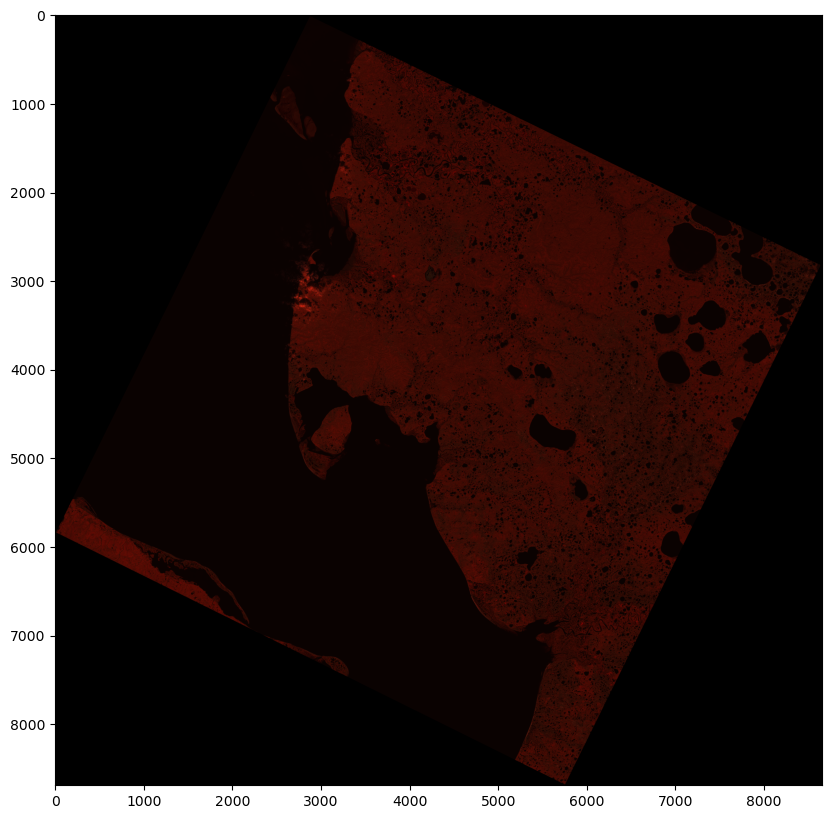

In [21]:
###################################
# Generate png from tiff
###################################

tiff_path = '/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/tiff_rgb'
out_path = '/data/rrs/seaice/aux_data/s1/tundra_lakes/Siberia/png_rgb'
os.makedirs(tiff_path, exist_ok=True)

ffiles = glob.glob(f'''{tiff_path}/*LC08*.tiff''')

for ifile in ffiles:
    print(ifile)
    img = gdal.Open(ifile).ReadAsArray()
    img = np.moveaxis(img, 0, -1)
    plt.imshow(img)
    plt.savefig(f'''{out_path}/{os.path.basename(ifile)}.png''',
                bbox_inches='tight', dpi=150)
    del img

In [94]:
###################################
# Generate png from tiff
###################################

import os
from osgeo import gdal

def geotiff_to_png(input_path, output_path=None, return_object=False):
    """
    Converts a GeoTIFF file to a PNG file or object. 
    
    Args:
        input_path (str): The file path of the input GeoTIFF file.
        output_path (str, optional): The file path of the output PNG file. If not provided, PNG object is returned. Defaults to None.
        return_object (bool, optional): Whether to return the PNG data as an object. If True, the output_path parameter will be ignored. Defaults to False.

    Returns:
        numpy.ndarray or None: If output_path is not provided and return_object is True, returns a 3D numpy array representing the PNG image. Otherwise, returns None.

    """
    
    # Open input file
    dataset = gdal.Open(input_path)
    output_types = [gdal.GDT_Byte, gdal.GDT_UInt16, gdal.GDT_Float32]
    
    stats = [dataset.GetRasterBand(i+1).GetStatistics(True, True) for i in range(dataset.RasterCount)]

    vmin, vmax, vmean, vstd = zip(*stats)
    # With those statistics you should be able to come up with some desired stretching.
    # If you want to scale between the min and max for each band you could do:

    scaleParams = list(zip(*[vmin, vmax]))
    
    # Define output format and options
    options = gdal.TranslateOptions(format='PNG',
                                    bandList=[1],
                                    creationOptions=['WORLDFILE=YES'],
                                    outputType=output_types[0],
                                    scaleParams=scaleParams)
    
    # Translate to PNG
    if output_path is not None:
        gdal.Translate(output_path, dataset, options=options)
        print(f'Successfully saved PNG file to {output_path}')
    
    # Return PNG object
    if return_object:
        mem_driver = gdal.GetDriverByName('MEM')
        mem_dataset = mem_driver.CreateCopy('', dataset, 0)
        png_data = mem_dataset.ReadAsArray()
        return png_data
    
    dataset = None

tiff_path = '/data/rrs/seaice/aux_data/RCM/aom23/training/tiff'
out_path = '/data/rrs/seaice/aux_data/RCM/aom23/training/png'
os.makedirs(out_path, exist_ok=True)

ffiles = glob.glob(f'''{tiff_path}/*.tif''')

for ifile in ffiles:
    print(ifile)
    out_file = f"""{out_path}/{os.path.basename(ifile).replace('tif', 'png')}"""
    geotiff_to_png(ifile, output_path=out_file, return_object=False)


/data/rrs/seaice/aux_data/RCM/aom23/training/tiff/RCM2_OK2561900_PK2577027_1_SC100MHVD_20230530_063610_HH_VV_GRD_HH_50m.tif
Successfully saved PNG file to /data/rrs/seaice/aux_data/RCM/aom23/training/png/RCM2_OK2561900_PK2577027_1_SC100MHVD_20230530_063610_HH_VV_GRD_HH_50m.png
/data/rrs/seaice/aux_data/RCM/aom23/training/tiff/RCM2_OK2561900_PK2577166_1_SC100MHVA_20230530_081304_HH_VV_GRD_HH_50m.tif
Successfully saved PNG file to /data/rrs/seaice/aux_data/RCM/aom23/training/png/RCM2_OK2561900_PK2577166_1_SC100MHVA_20230530_081304_HH_VV_GRD_HH_50m.png
/data/rrs/seaice/aux_data/RCM/aom23/training/tiff/RCM3_OK2561900_PK2577110_1_SC100MHVC_20230530_074134_HH_VV_GRD_HH_50m.tif
Successfully saved PNG file to /data/rrs/seaice/aux_data/RCM/aom23/training/png/RCM3_OK2561900_PK2577110_1_SC100MHVC_20230530_074134_HH_VV_GRD_HH_50m.png
/data/rrs/seaice/aux_data/RCM/aom23/training/tiff/RCM2_OK2561900_PK2577027_2_SC100MHVD_20230530_063610_HH_VV_GRD_HH_50m.tif
Successfully saved PNG file to /data/rrs/s

In [91]:
out_file

'/data/rrs/seaice/aux_data/RCM/aom23/training/png/<function basename at 0x7f0f58aa6e60>'